In [ ]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cu128'

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant, 1 = benign

print(df.shape)          # (569, 31)
print(df.dtypes)         # all float
print(df.isnull().sum()) # no missing values

(569, 31)
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symm

In [ ]:
#df.head()
df.sample(5) #random

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
103,9.876,19.40,63.95,298.3,0.10050,0.09697,0.06154,0.03029,0.1945,0.06322,...,26.83,72.22,361.2,0.1559,0.2302,0.26440,0.09749,0.2622,0.08490,1
399,11.800,17.26,75.26,431.9,0.09087,0.06232,0.02853,0.01638,0.1847,0.06019,...,24.49,86.00,562.0,0.1244,0.1726,0.14490,0.05356,0.2779,0.08121,1
468,17.600,23.33,119.00,980.5,0.09289,0.20040,0.21360,0.10020,0.1696,0.07369,...,28.87,143.60,1437.0,0.1207,0.4785,0.51650,0.19960,0.2301,0.12240,0
281,11.740,14.02,74.24,427.3,0.07813,0.04340,0.02245,0.02763,0.2101,0.06113,...,18.26,84.70,533.7,0.1036,0.0850,0.06735,0.08290,0.3101,0.06688,1
41,10.950,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,35.34,87.22,514.0,0.1909,0.2698,0.40230,0.14240,0.2964,0.09606,0


In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
import numpy as np

# Define the target column
target_column = "target"

# Separate features and labels for X
X = df.drop(columns=[target_column])
y = df["target"]



print("X head:")
display(X.head())
print("\ny  head:")
display(y.head())


X head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



y  head:


,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Split data
"""
Non profeesional in nature
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
"""
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(y_train), len(X_test), len(y_test)

(455, 455, 114, 114)

The reason your model isn't learning (the loss stays exactly the same) is primarily due to feature scaling.

Looking at your data, columns like mean area have values over 1000, while mean smoothness is around 0.1. In PyTorch, using SGD without scaling these features often leads to 'vanishing' or 'exploding' gradients, where the model gets stuck immediately.

I'll add a step to scale your data to a standard range (mean=0, variance=1), which should allow the loss to start decreasing.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
# It's important to fit ONLY on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"New range of first 5 rows of X_train_scaled:\n{X_train_scaled[:5, :2]}")

Features scaled successfully.
New range of first 5 rows of X_train_scaled:
[[-1.44075296 -0.43531947]
 [ 1.97409619  1.73302577]
 [-1.39998202 -1.24962228]
 [-0.98179678  1.41622208]
 [-1.11769991 -1.0102595 ]]


In [ ]:
# Update the NumPy arrays and tensors to use the scaled data
X_train_np = X_train_scaled
X_test_np = X_test_scaled

print("Shape of X_features_np:", X_train_np.shape)
print("First 5 rows of X_features_np:\n", X_train_np[:5])
print("\nShape of y_features_np:", X_test_np.shape)
print("First 5 rows of y_features_np:\n", X_test_np[:5])



# Re-convert to tensors
X_train_tensor = torch.from_numpy(X_train_np).float()
X_test_tensor = torch.from_numpy(X_test_np).float()

# Re-assign to variables used in training

# Convert labels to PyTorch tensors
y_train_tensor = torch.from_numpy(y_train.values).float()
y_test_tensor = torch.from_numpy(y_test.values).float()


X_train=X_train_tensor
X_test=X_test_tensor
y_train=y_train_tensor
y_test=y_test_tensor

print("Shape of X_features_tensor:", X_train_tensor.shape)
print("First 5 rows of X_features_tensor:\n", X_train_tensor[:5])
print("\nShape of y_features_tensor:", X_test_tensor.shape)
print("First 5 rows of y_features_tensor:\n", X_test_tensor[:5])

print("\nShape of X_labels_tensor:", y_train_tensor.shape)
print("First 5 rows of X_labels_tensor:\n", y_train_tensor[:5])

print("\nShape of y_labels_tensor:",y_test_tensor.shape)
print("First 5 rows of y_labels_tensor:\n", y_test_tensor[:5])

print("Tensors updated with scaled data. You can now re-run the model definition and training cells.")

Shape of X_features_np: (455, 30)
First 5 rows of X_features_np:
 [[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.12095781 -0.35077918  0.57276579  0.7394

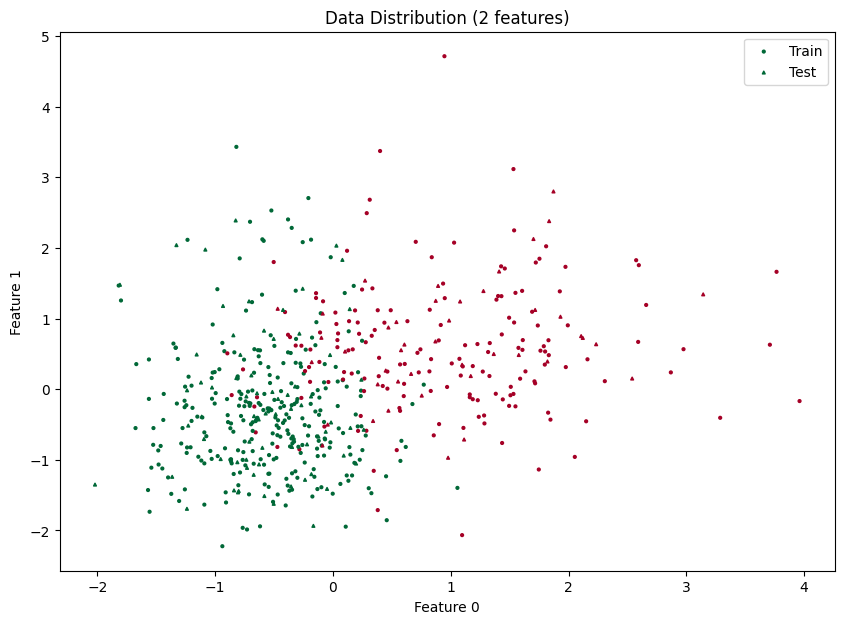

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(X_train[:, 0].cpu(), X_train[:, 1].cpu(), c=y_train.cpu().squeeze(), cmap="RdYlGn", s=4, label="Train")
plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap="RdYlGn", s=4, marker="^", label="Test")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Data Distribution (2 features)")
plt.legend()
plt.show()

In [ ]:
class LogisticRegressionModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=X_train.shape[1],
                                      out_features=1)

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.linear_layer(x))
# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LogisticRegressionModelV1()
model_1, model_1.state_dict()

(LogisticRegressionModelV1(
   (linear_layer): Linear(in_features=30, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight',
               tensor([[ 0.1396,  0.1515, -0.0428,  0.1677, -0.0400,  0.0368, -0.0889,  0.1072,
                         0.1609, -0.1339,  0.1587,  0.0342,  0.1349,  0.0247,  0.0880, -0.0258,
                         0.1407,  0.0270, -0.0852,  0.0465, -0.0841, -0.0214, -0.0742,  0.1211,
                        -0.1441, -0.0842, -0.0516, -0.1098,  0.0172, -0.1803]])),
              ('linear_layer.bias', tensor([0.1649]))]))

In [ ]:
torch.manual_seed(42)
#Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_1 = LogisticRegressionModelV1()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_1.parameters())

[Parameter containing:
 tensor([[ 0.1396,  0.1515, -0.0428,  0.1677, -0.0400,  0.0368, -0.0889,  0.1072,
           0.1609, -0.1339,  0.1587,  0.0342,  0.1349,  0.0247,  0.0880, -0.0258,
           0.1407,  0.0270, -0.0852,  0.0465, -0.0841, -0.0214, -0.0742,  0.1211,
          -0.1441, -0.0842, -0.0516, -0.1098,  0.0172, -0.1803]],
        requires_grad=True),
 Parameter containing:
 tensor([0.1649], requires_grad=True)]

In [ ]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Create loss function
loss_fn = nn.BCELoss()


# Create optimizer (Adam)

optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.01)

In [ ]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data on the available device
X_train = X_train.to(device)
X_test = X_test.to(device)

# Safely reshape labels only if they are 1D (shape [N] -> [N, 1])
# This prevents [N, 1] from becoming [N, 1, 1] on re-runs
if y_train.ndim == 1:
    y_train = y_train.to(device).unsqueeze(1)
else:
    y_train = y_train.to(device)

if y_test.ndim == 1:
    y_test = y_test.to(device).unsqueeze(1)
else:
    y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.83218 | Test loss: 0.81522
Epoch: 100 | Train loss: 0.25784 | Test loss: 0.24186
Epoch: 200 | Train loss: 0.19269 | Test loss: 0.17487
Epoch: 300 | Train loss: 0.16405 | Test loss: 0.14538
Epoch: 400 | Train loss: 0.14717 | Test loss: 0.12815
Epoch: 500 | Train loss: 0.13574 | Test loss: 0.11666
Epoch: 600 | Train loss: 0.12735 | Test loss: 0.10839
Epoch: 700 | Train loss: 0.12087 | Test loss: 0.10211
Epoch: 800 | Train loss: 0.11565 | Test loss: 0.09717
Epoch: 900 | Train loss: 0.11135 | Test loss: 0.09318


In [ ]:
# Find our model's learned parameters
from pprint import pprint # pprint = pretty print, see: https://docs.python.org/3/library/pprint.html
print("The model learned the following values for weights and bias:")
pprint(model_1.state_dict())


The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight',
              tensor([[-0.2926, -0.2743, -0.4667, -0.2578, -0.1374, -0.0568, -0.3779, -0.2990,
          0.0374,  0.1047, -0.2489, -0.0397, -0.2078, -0.3269,  0.0452,  0.0757,
          0.1871, -0.0917, -0.0497,  0.2263, -0.5659, -0.4790, -0.5294, -0.3319,
         -0.3430, -0.2115, -0.2892, -0.4775, -0.2400, -0.1485]],
       device='cuda:0')),
             ('linear_layer.bias', tensor([0.4378], device='cuda:0'))])


In [ ]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
    y_preds_labels = (y_preds > 0.5).float()
y_preds_labels

tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
      

In [ ]:
# Accuracy
import torch
!pip install torchmetrics
from torchmetrics import Accuracy
acc = Accuracy(task="binary").to(device)
print(f"Accuracy: {acc(y_preds_labels, y_test):.4f}")

Accuracy: 0.9825


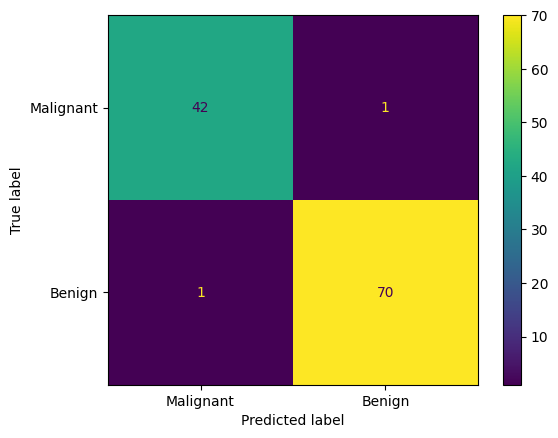

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test.cpu(), y_preds_labels.cpu())
ConfusionMatrixDisplay(cm, display_labels=["Malignant", "Benign"]).plot()

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LogisticRegressionModelV1()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LogisticRegressionModelV1(
  (linear_layer): Linear(in_features=30, out_features=1, bias=True)
)
Model on device:
cuda:0


In [ ]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        